# Base Ouro - Grupo 5

## Relatório técnico e interpretativo: V1 oficial, V2 complementar

**Fechamento:** 04/10/2026  
**Escopo:** exclusivamente Grupo 5 / Ouro  
**Regra de leitura:** V1 define o ranking oficial; V2 explica limitações e caminhos futuros.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

def find_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'analyses' / 'grupo5' / 'outputs').exists():
            return candidate
    raise FileNotFoundError('Execute o notebook dentro do repositório pls-regration.')

ROOT = find_root()
OUT = ROOT / 'analyses' / 'grupo5' / 'outputs'
REPORT = ROOT / 'analyses' / 'grupo5' / '05_relatorio'
V2 = REPORT / 'evidencias_v2'

def figure(relative_path, width=1000):
    path = OUT / relative_path
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path), width=width))

def report_figure(name, width=1000):
    path = REPORT / 'assets' / name
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path), width=width))

print('Composição leve: somente leitura de CSV, JSON e imagens existentes.')


Composição leve: somente leitura de CSV, JSON e imagens existentes.


## 1. Resumo executivo

Este relatório trata exclusivamente da **base Ouro do Grupo 5**. A V1 permanece a modelagem oficial; a V2 entra apenas como estudo complementar para explicar dificuldade do alvo, extrapolação do Random Forest, ablation, drift e redundância. Nenhum resultado congelado foi recalculado.

No teste final, Holt-Winters obteve o menor MAE, 11,5331 USD/onça troy, seguido de SARIMAX (11,5988), PLS Regression (11,6002) e Random Forest (14,2826). Persistência marcou 11,6377 e permanece fora do ranking. A vantagem do primeiro colocado sobre persistência foi somente 0,90%, de modo que Holt-Winters, SARIMAX e PLS devem ser apresentados como resultados muito próximos, não como uma vitória ampla.

O achado central é interpretativo: em horizonte de uma observação, o preço recente domina; a dificuldade cresceu no período de teste; e o RF em LEVEL encontrou um regime no qual quase todos os alvos ultrapassavam o máximo observado no treino. A V2 reforça essa leitura, mas não substitui a V1.

model,n_forecasts,mae,rank_gold
Holt_Winters,296,11.5331,1
SARIMAX,296,11.5988,2
PLS_Regression,296,11.6002,3
Random_Forest,296,14.2826,4


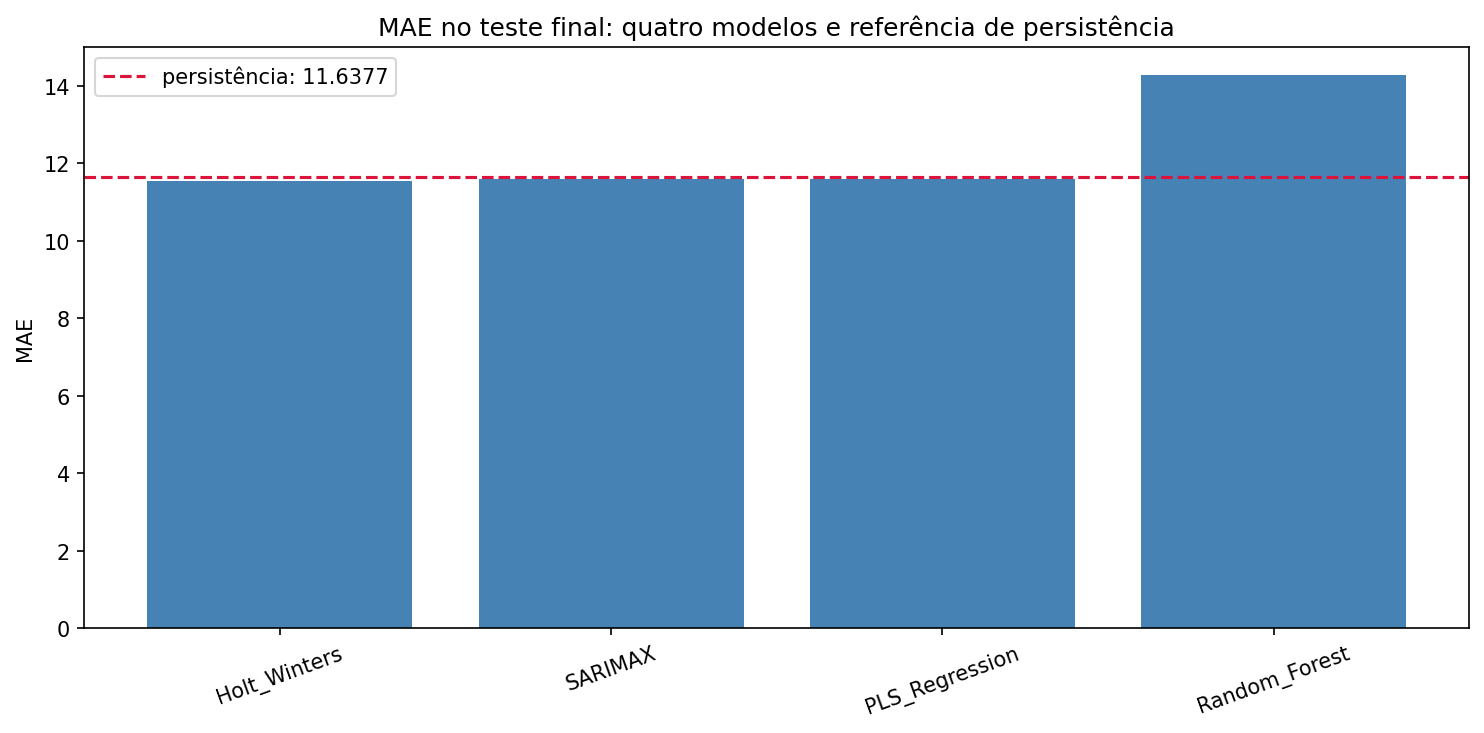

In [2]:
ranking = pd.read_csv(OUT / 'metrics.csv').sort_values('rank_gold')
display(ranking[['model','n_forecasts','mae','rank_gold']].round({'mae': 4}))
figure('mae_comparison_gold.png', 900)

## 2. Base, qualidade e causalidade temporal

O alvo é o preço do ouro na próxima observação real do calendário bruto. A série corresponde ao fixing da tarde de Londres da Deutsche Bundesbank, código `BBEX3.D.XAU.USD.EA.AC.C05`, em USD por onça fina. O arquivo usado cobre 01/04/1968 a 10/04/2014.

Dos 12.009 registros brutos, 11.641 têm preço válido e 368 estão ausentes. O ouro não foi interpolado. A base modelável final tem 9.864 observações e 12 features causais. Treasury 10Y e Fed Funds foram alinhadas ao calendário do ouro por `left merge`, preenchidas somente para frente e defasadas uma observação. Não houve `backfill`.

A auditoria reconstruiu todas as linhas e confirmou que `TARGET = GOLD_PRICE.shift(-1)` foi criado antes do filtro modelável. Em 428 casos, o alvo não coincide com a próxima linha modelável, mas continua apontando corretamente para o próximo preço do calendário bruto. Não foi encontrada evidência de leakage, deslocamento temporal ou previsão não finita.

item,valor,detalhe
periodo_serie_bruta,1968-04-01 a 2014-04-10,"período do arquivo de referência, incluindo datas com preço ausente"
registros_brutos,12009,todas as linhas do arquivo de ouro
registros_com_preco_valido,11641,linhas com GOLD_PRICE numérico
registros_modelaveis,9864,"linhas após exigir alvo, lags, janelas e externas causais disponíveis"
frequencia_observada,"dias de mercado, calendário irregular",mediana do intervalo entre preços válidos = 1 dia(s)
unidade,USD por onça fina de ouro,unidade oficial documentada para a série
fonte,CSV de referência gold.daily.prices.csv,fixing da tarde em Londres; código BBEX3.D.XAU.USD.EA.AC.C05
significado,preço diário do ouro no fixing da tarde em Londres,"série de preço, não retorno"
duplicidades_data_bruta,0,datas repetidas no arquivo bruto
duplicidades_data_modelavel,0,datas repetidas na base usada pelos modelos


verificação,valor
linhas no arquivo bruto,12009
preços ausentes no arquivo bruto,368
linhas na base modelada,9864
nulos na base modelada,0
datas duplicadas,0
maior intervalo entre observações (dias),20
intervalos maiores que 3 dias,401
extremos pelo IQR no nível do preço,1416
retornos extremos pelo MAD,480


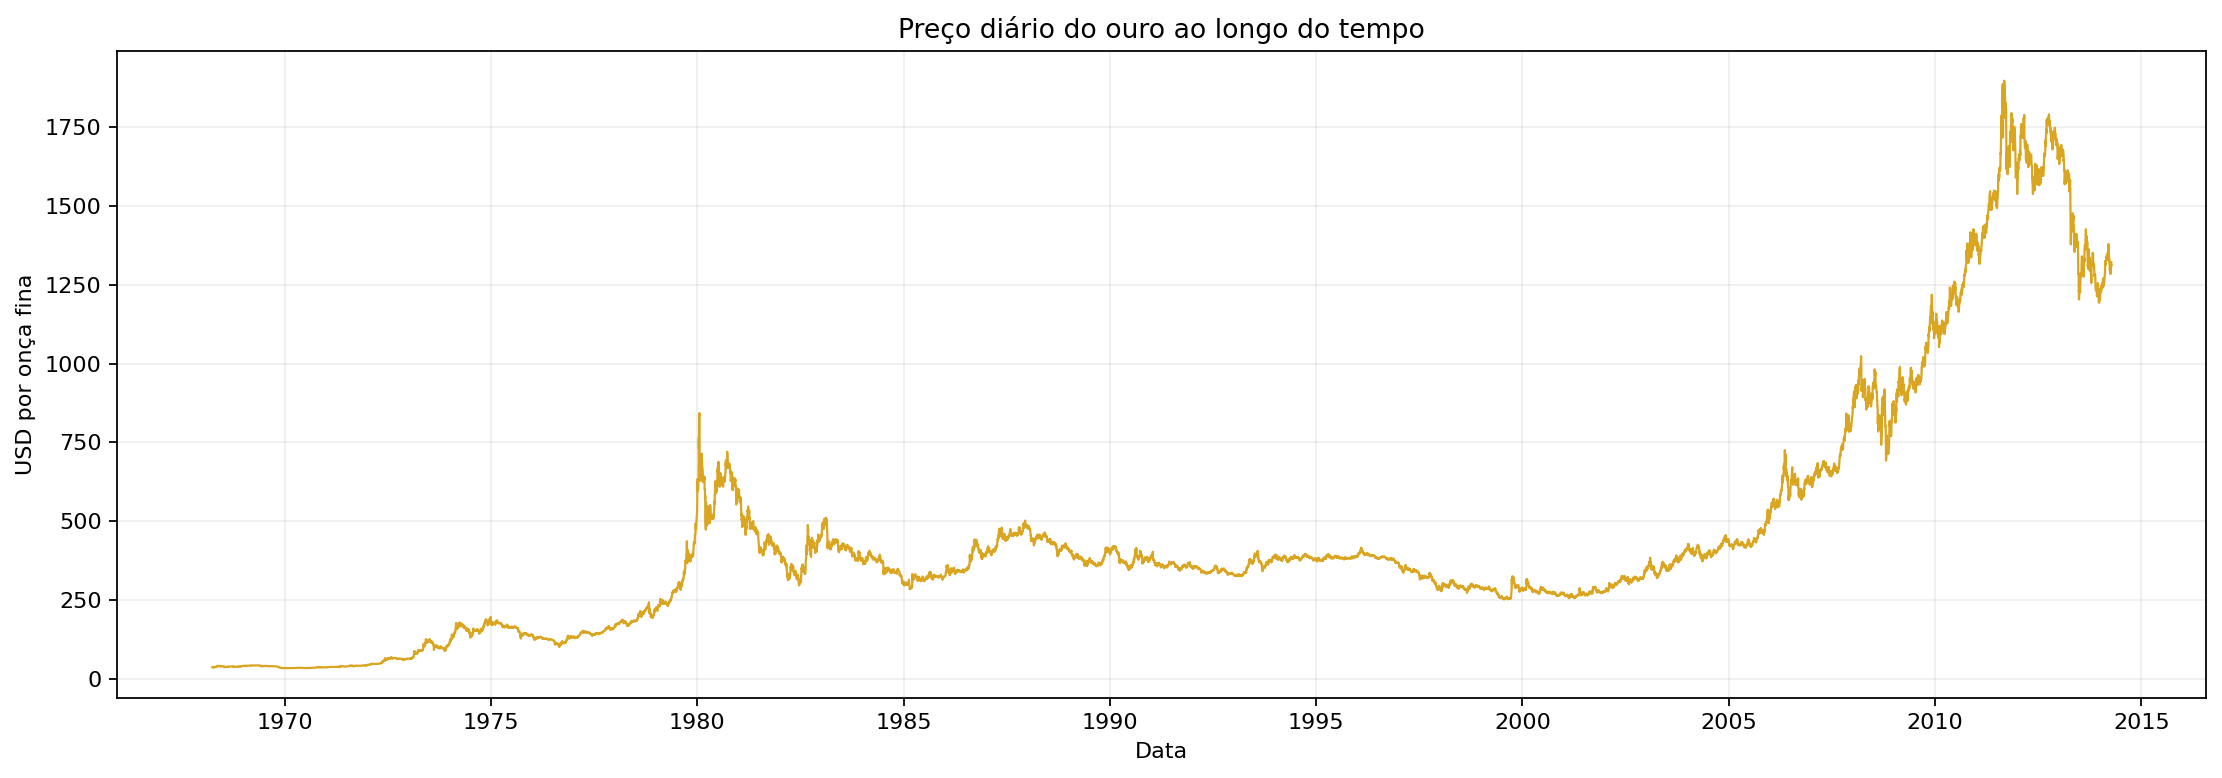

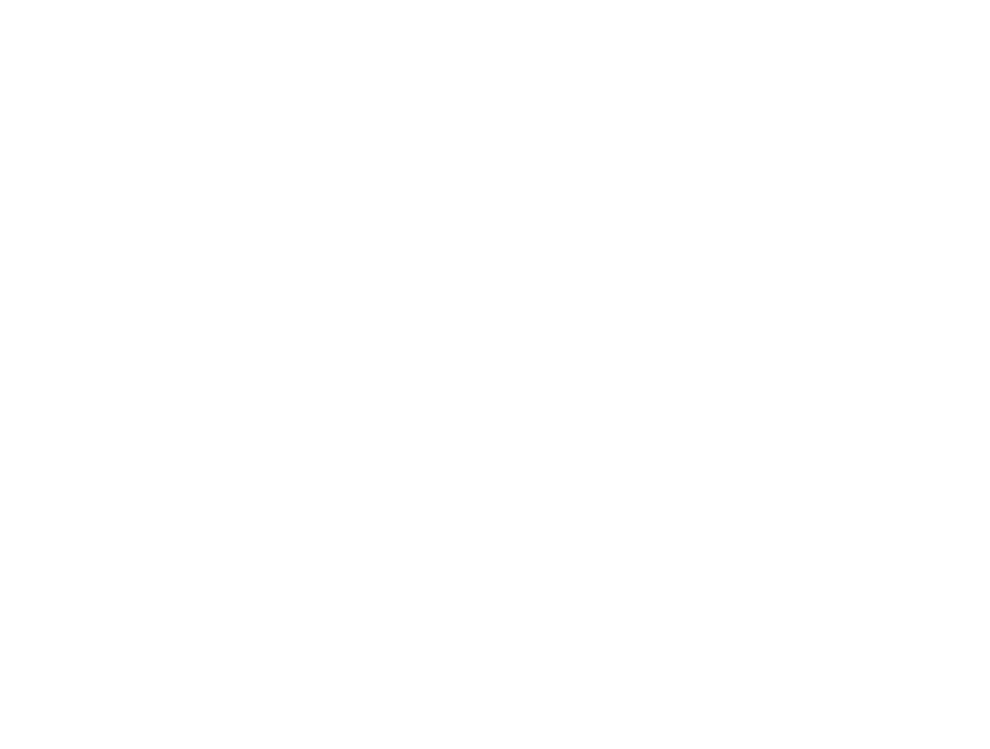

In [3]:
display(pd.read_csv(OUT / 'exploratory_summary.csv'))
display(pd.read_csv(OUT / 'data_quality_audit.csv'))
figure('graficos/gold_price_full.png', 980)
figure('01_data_quality_outliers.png', 980)

## 3. STL, features e prevenção de leakage

A STL foi ajustada somente no treino. Nos períodos 5, 20 e 252, a força sazonal foi 0,0; a tendência foi o componente dominante. O período 5 permaneceu como referência operacional de semana de mercado em algumas configurações, não como evidência de sazonalidade forte.

RF e PLS usam a mesma matriz de 12 features: nível atual, lags 1/5/20, média e desvio móvel dos cinco preços anteriores, calendário cíclico e duas externas. As janelas usam `shift(1)` antes do cálculo; `TARGET` e `TARGET_UP` não entram como features. O PLS reajusta o `StandardScaler` dentro de cada janela de treino.

period,seasonal_strength,trend_strength,residual_std
5,0.0,0.9984,6.0593
20,0.0,0.9907,14.3810
252,0.0,0.9225,41.6081


nome,tipo,informacao_usada,conhecida_na_origem
GOLD_PRICE,preço observado na origem,preço do ouro disponível na origem,sim
TREASURY_10Y,variável externa defasada,último DGS10 disponível antes da origem,sim
FED_FUNDS_RATE,variável externa defasada,último DFF disponível antes da origem,sim
DOW_SIN,calendário cíclico,dia da semana da origem,sim
DOW_COS,calendário cíclico,dia da semana da origem,sim
MONTH_SIN,calendário cíclico,mês da origem,sim
MONTH_COS,calendário cíclico,mês da origem,sim
GOLD_LAG_1,lag de preço,preço de uma observação bruta anterior,sim
GOLD_LAG_5,lag de preço,preço de cinco observações brutas anteriores,sim
GOLD_LAG_20,lag de preço,preço de vinte observações brutas anteriores,sim


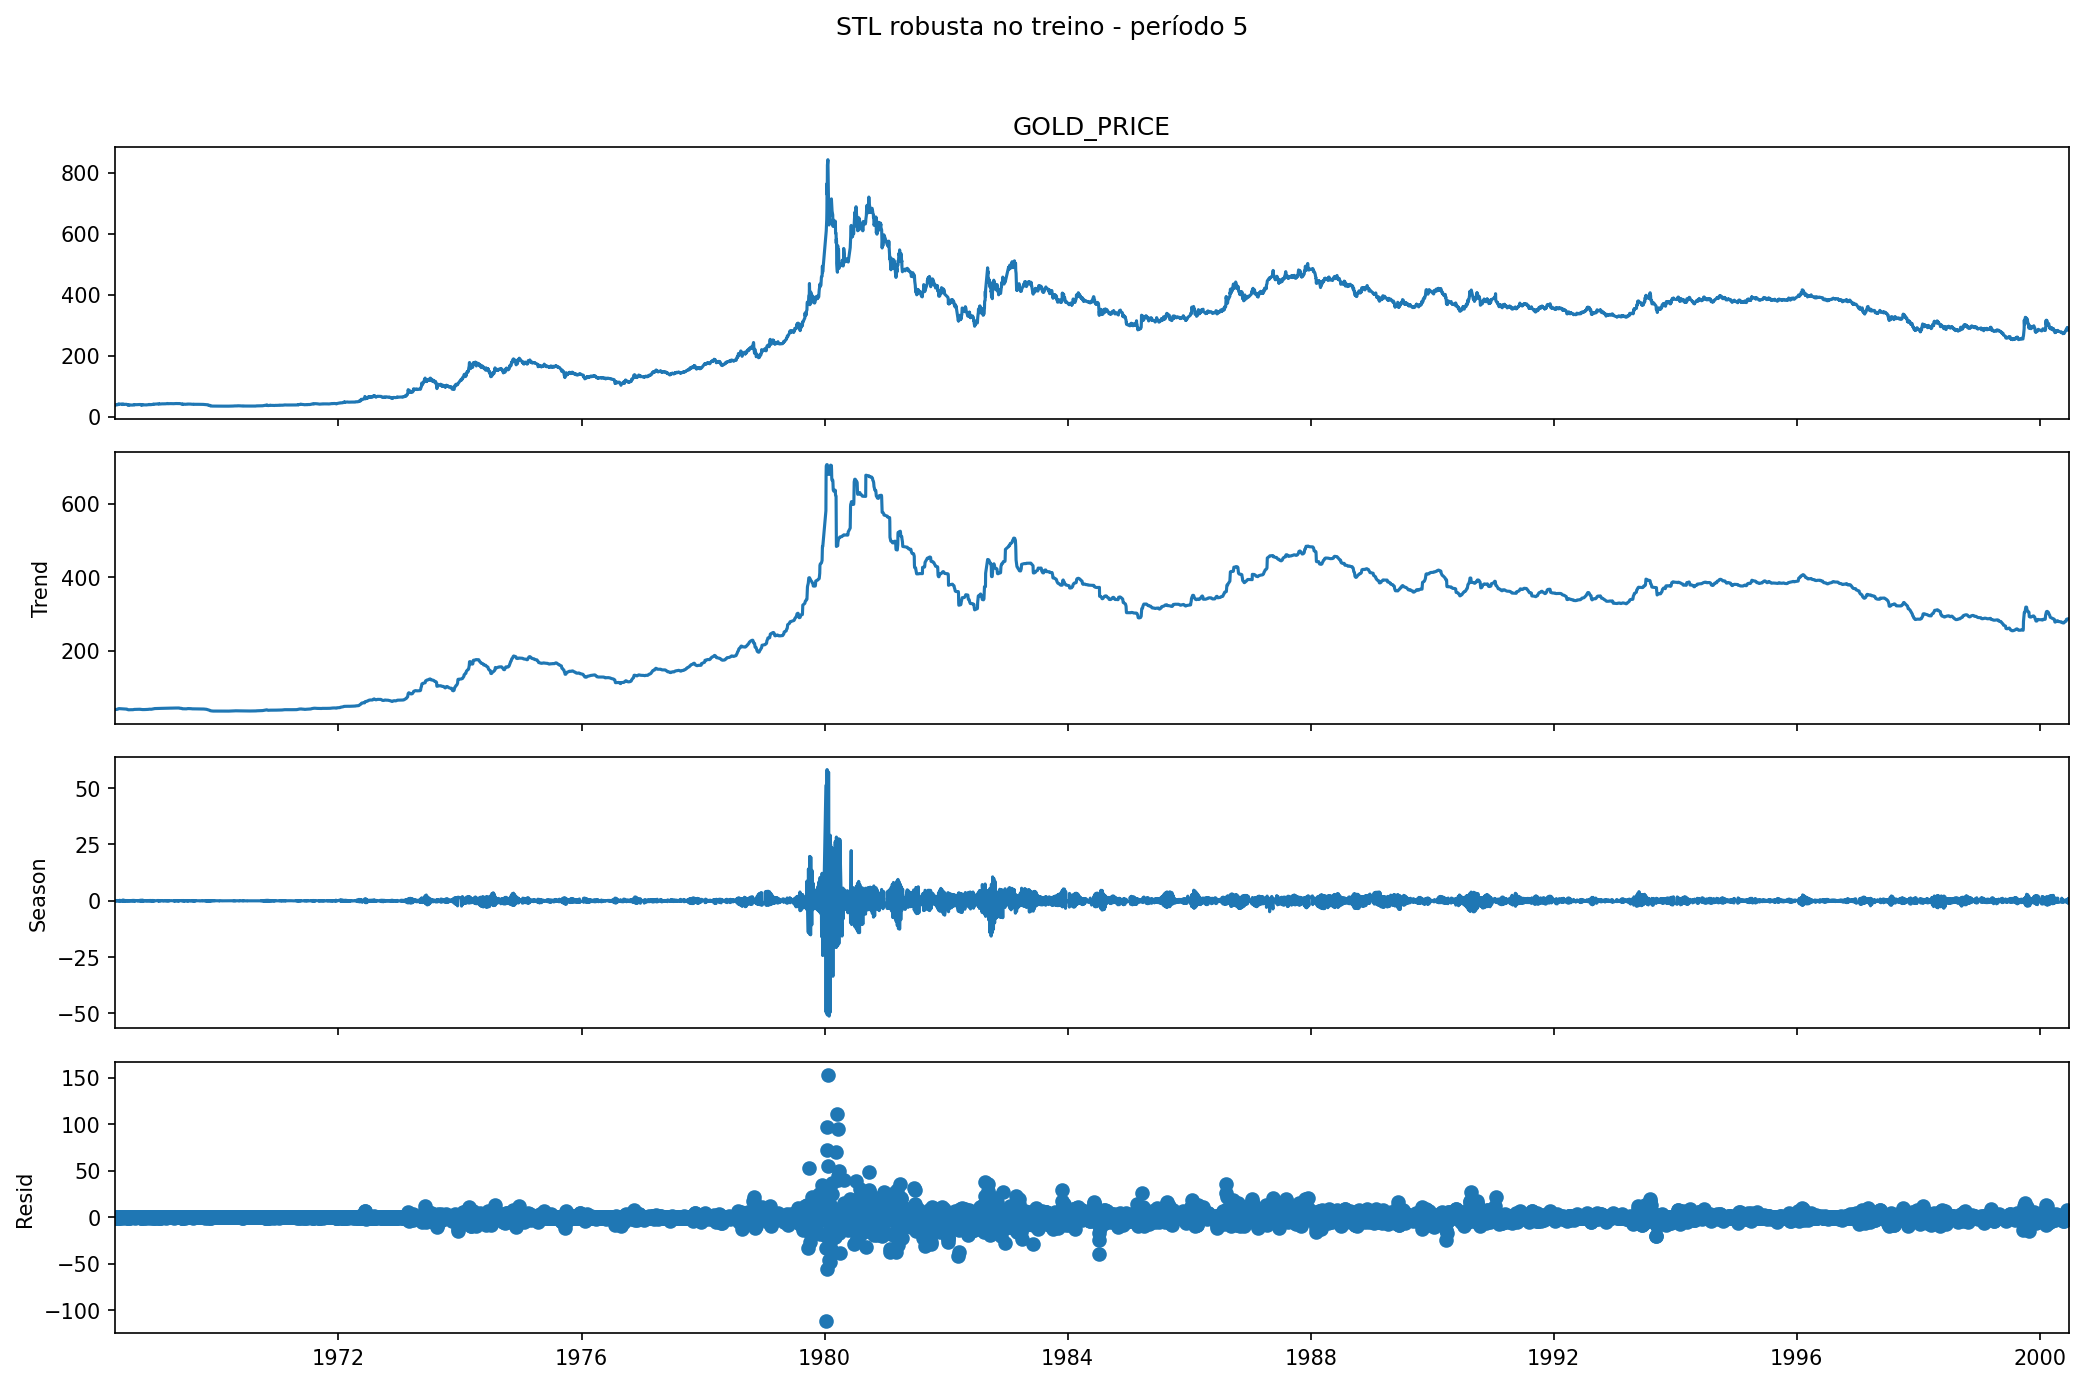

In [4]:
display(pd.read_csv(OUT / 'stl_candidates.csv').round(4))
display(pd.read_csv(OUT / 'feature_dictionary.csv')[['nome','tipo','informacao_usada','conhecida_na_origem']])
figure('stl_period_5.png', 980)

## 4. Protocolo experimental e tuning congelado

A base foi dividida cronologicamente em 70% treino, 15% validação e 15% teste. O walk-forward usa janela expansiva, horizonte de uma observação e passo cinco, com 296 origens de validação e 296 de teste. Os quatro modelos compartilham origens, datas-alvo e `Y_TRUE`.

Tuning ocorreu somente em treino e validação. O teste final avaliou configurações congeladas: SARIMAX `(0,1,2) x (0,0,1,5)`; Holt-Winters aditivo com período 5; RF com 300 árvores, profundidade 20, folha mínima 5, divisão mínima 10 e `max_features=1.0`; PLS com 11 componentes. Nenhuma decisão foi reaberta nesta finalização.

model,parameters,validation_mae,n_candidates
SARIMAX,"{""order"": [0, 1, 2], ""seasonal_order"": [0, 0, 1, 5]}",2.9844,5
Holt_Winters,"{""damped_trend"": false, ""seasonal"": ""add"", ""seasonal_periods"": 5, ""trend"": ""add""}",2.9760,15
Random_Forest,"{""max_depth"": 20, ""max_features"": 1.0, ""min_samples_leaf"": 5, ""min_samples_split"": 10, ""n_estimators"": 300}",3.3263,12
PLS_Regression,"{""n_components"": 11}",2.9701,12


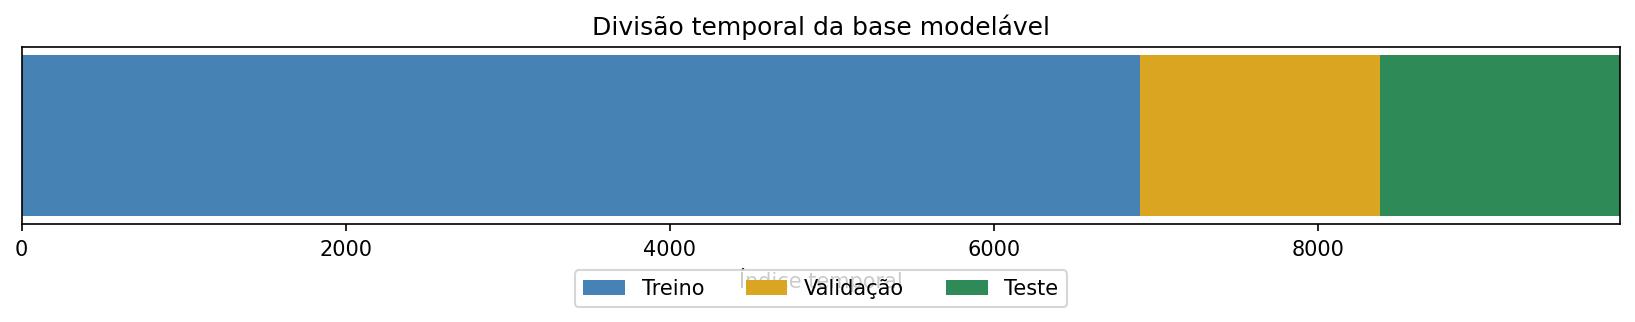

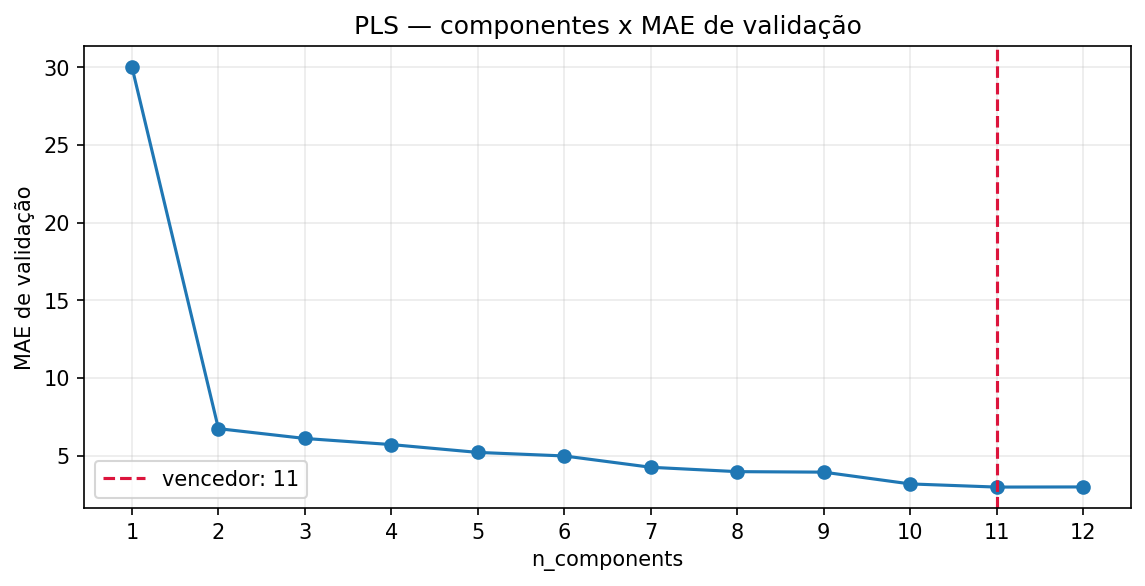

In [5]:
hp = pd.read_csv(OUT / 'hyperparameters.csv')
display(hp[['model','parameters','validation_mae','n_candidates']].round({'validation_mae': 4}))
figure('graficos/walkforward_split_timeline.png', 980)
figure('pls_validation_components.png', 900)

## 5. MAE, persistência e mudança de dificuldade

MAE está expresso em USD por onça troy. Nas mesmas 296 origens de teste, o movimento absoluto médio origem-alvo foi 11,6377 e a mediana foi 8,50. Holt-Winters teve MAE equivalente a aproximadamente 99,1% desse movimento médio: é o menor erro formal, mas sua melhora sobre persistência foi inferior a 1%.

O PLS teve MAE de validação 2,9701 e MAE de teste 11,6002. Não há mudança de unidade: são dois blocos temporais diferentes. O histórico completo teve movimento absoluto médio de cerca de 3,8893 USD/onça, contra 11,6377 nas origens oficiais de teste. A diferença mostra aumento importante de escala e volatilidade no teste, sem provar uma causa econômica específica.

Persistência é diagnóstico, não quinto modelo oficial. Ela é especialmente relevante para preços em horizonte curto e impede que pequenas diferenças sejam interpretadas como grande ganho preditivo.

model,mae,baseline_persistence_mae,improvement_pct_vs_persistence
Holt_Winters,11.5331,11.6377,0.8986
SARIMAX,11.5988,11.6377,0.3336
PLS_Regression,11.6002,11.6377,0.3219
Random_Forest,14.2826,11.6377,-22.7275


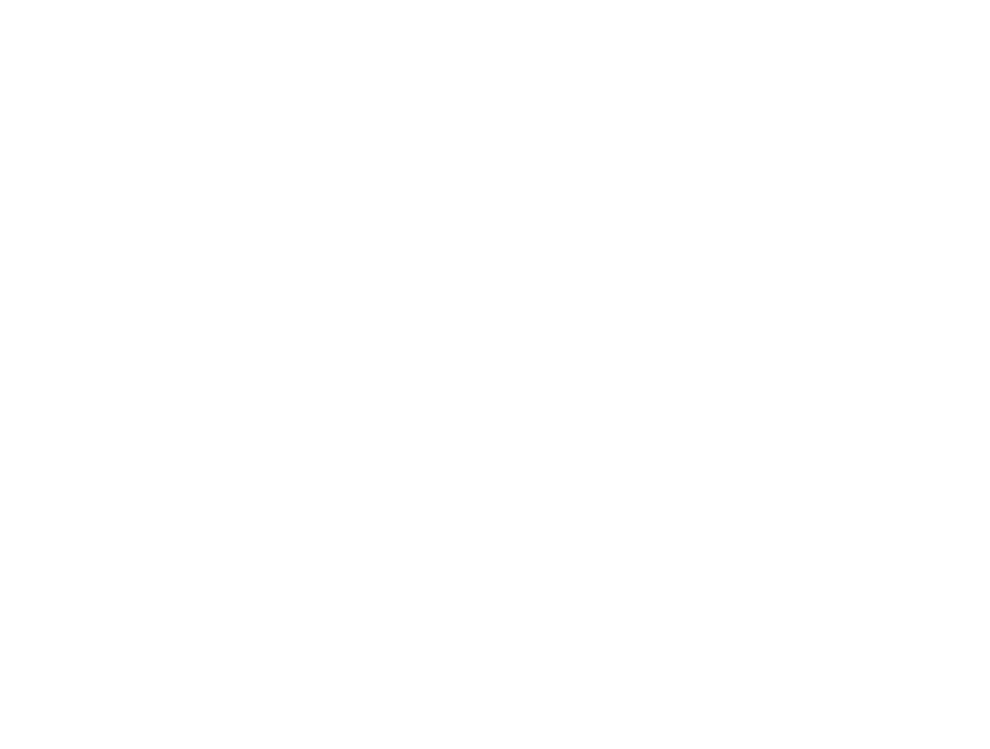

In [6]:
ctx = pd.read_csv(OUT / 'model_comparison_vs_baseline.csv').sort_values('rank_gold')
display(ctx[['model','mae','baseline_persistence_mae','improvement_pct_vs_persistence']].round(4))
figure('model_predictions_comparison.png', 980)

## 6. Resíduos e Ljung-Box

Os resíduos fora da amostra são `real - previsto`. Holt-Winters e PLS tiveram média próxima de zero e nenhuma rejeição nos 20 lags avaliados. SARIMAX teve uma rejeição isolada. RF apresentou três rejeições, maior dispersão e viés médio positivo, compatível com subestimação média e estrutura residual remanescente.

O Ljung-Box avalia autocorrelação conjunta até cada lag. Ausência de rejeição não prova independência perfeita; rejeições pontuais também não bastam para explicar todo o erro. A tabela completa de 80 resultados fica no apêndice técnico.

model,media_residuos,desvio_padrao_residuos,rejected_lags_5pct,p_value_lag_20
Holt_Winters,0.1131,15.7363,0,0.4041
PLS_Regression,0.2337,15.8807,0,0.3550
Random_Forest,3.1615,20.5757,3,0.4008
SARIMAX,0.3621,15.7470,1,0.3162


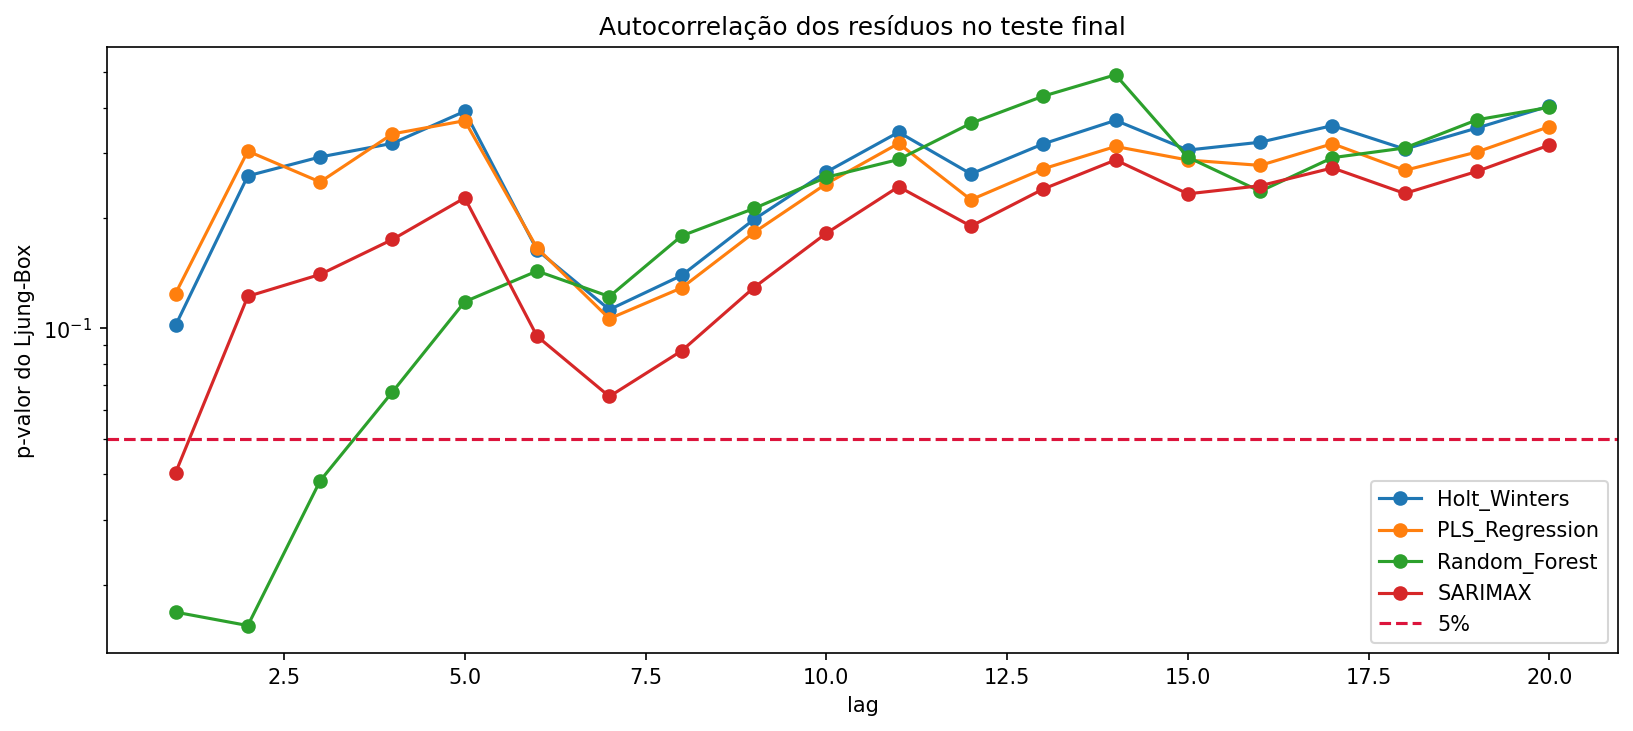

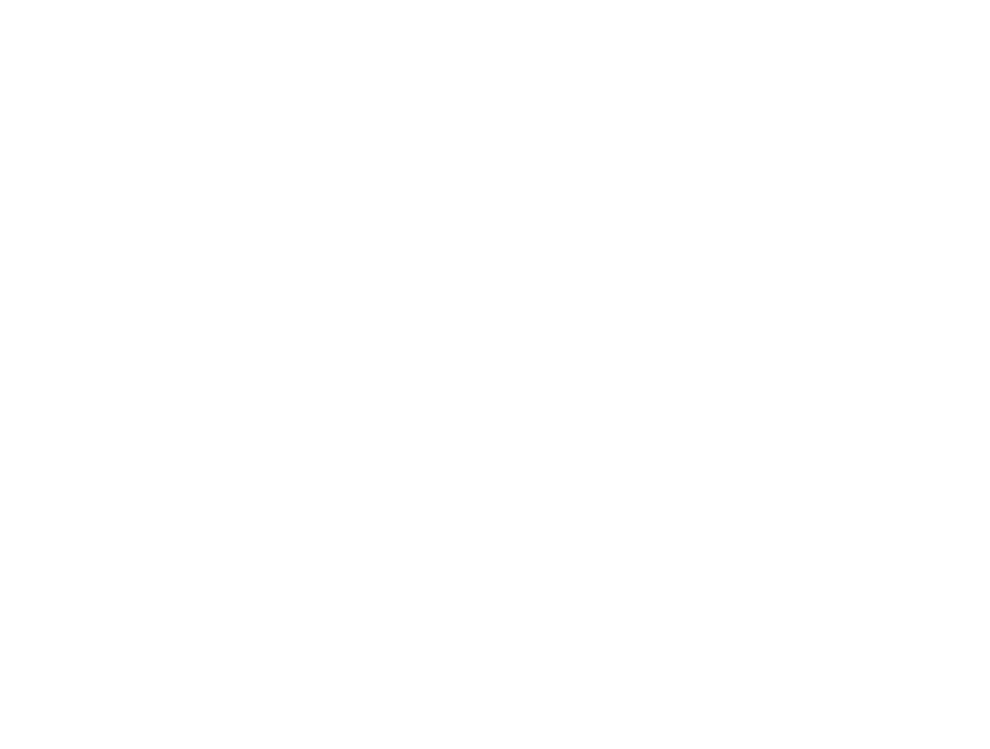

In [7]:
res = pd.read_csv(OUT / 'residual_diagnostics_summary.csv')
display(res[['model','media_residuos','desvio_padrao_residuos','rejected_lags_5pct','p_value_lag_20']].round(4))
figure('ljung_box_comparison.png', 900)
figure('residual_random_forest_serie.png', 900)

## 7. Importância das features

No RF, a importância nativa é dominada por `GOLD_PRICE` e `GOLD_LAG_1`. No PLS, coeficientes padronizados, VIP e permutation importance destacam preço atual, lag 1, média móvel e lags 5/20. A leitura é coerente com um horizonte de uma observação, no qual persistência e memória recente são fortes.

Importância não implica causalidade. Features correlacionadas podem dividir importância; sinais de coeficientes podem variar sob colinearidade; e externas com contribuição marginal pequena neste recorte não são evidência de ausência de relação econômica em outros regimes ou horizontes.

model,feature,vip_score,permutation_mean,permutation_rank
PLS_Regression,GOLD_PRICE,1.5003,347.9654,1
PLS_Regression,GOLD_LAG_1,1.4993,30.9009,2
PLS_Regression,GOLD_ROLLING_MEAN_5,1.4979,5.3264,3
PLS_Regression,GOLD_LAG_5,1.4958,1.4682,4
PLS_Regression,GOLD_LAG_20,1.4855,0.9784,5
Random_Forest,GOLD_PRICE,NaN,4.1544,1
Random_Forest,GOLD_LAG_1,NaN,0.2050,2
Random_Forest,FED_FUNDS_RATE,NaN,0.0253,3
Random_Forest,GOLD_ROLLING_STD_5,NaN,0.0027,4
Random_Forest,DOW_COS,NaN,0.0016,5


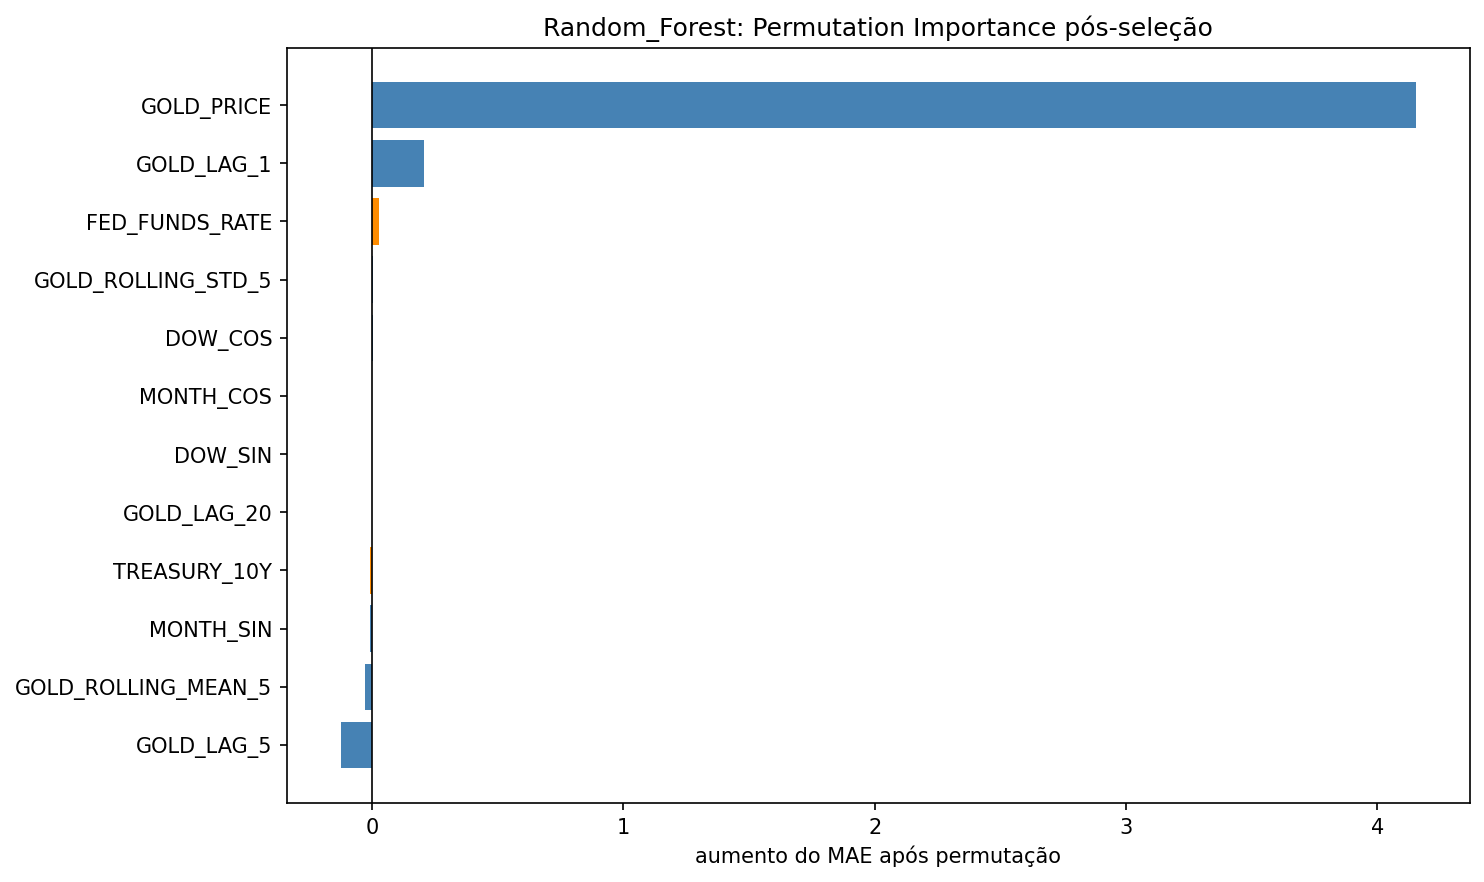

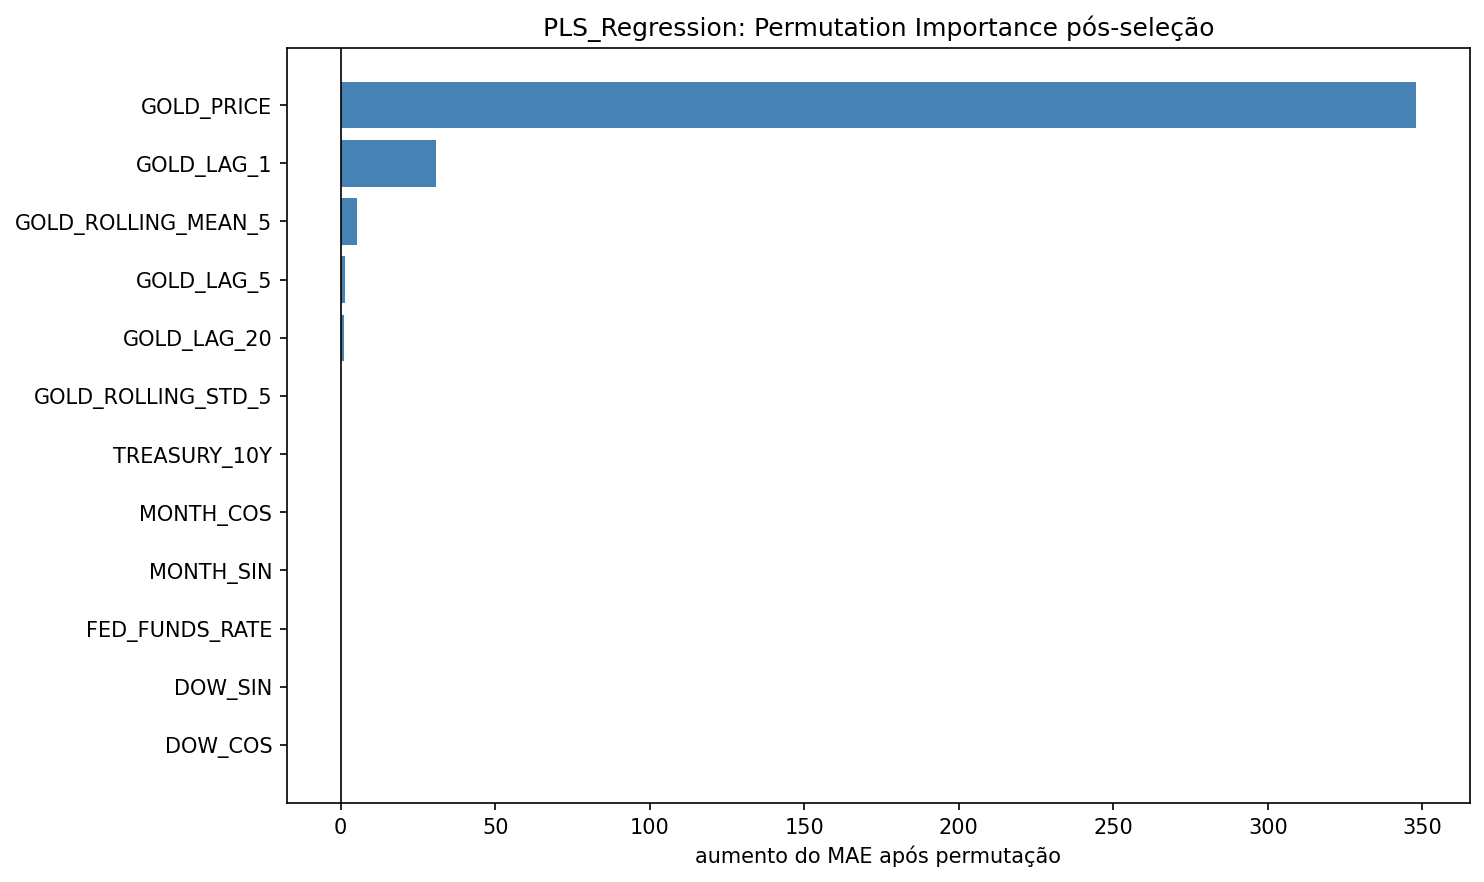

In [8]:
imp = pd.read_csv(OUT / 'feature_importance_summary.csv')
top = imp.sort_values(['model','permutation_rank']).groupby('model', group_keys=False).head(5)
display(top[['model','feature','vip_score','permutation_mean','permutation_rank']].round(4))
figure('feature_importance_random_forest.png', 900)
figure('feature_importance_pls_regression.png', 900)

## 8. PLS Regression: papel técnico e bloco didático reservado

PLS constrói componentes latentes orientados pela covariância entre `X` e `y`, o que ajuda quando preço atual, lags e médias móveis são correlacionados. Na V1, usou as mesmas 12 features causais do RF, com padronização reajustada em cada janela. A validação selecionou 11 componentes; portanto, a compressão foi pequena, 11 de 12 dimensões.

No teste, PLS marcou 11,6002, apenas 0,0671 acima de Holt-Winters e 0,0375 melhor que persistência. Coeficientes, VIP e permutação são leituras complementares e devem ser interpretados com cautela diante da colinearidade e da mudança temporal.

> **Bloco reservado - Explicação didática de PLS Regression.** A aula completa será incorporada posteriormente a partir do outro chat. O roteiro reserva 3 a 4 minutos para componentes latentes, colinearidade, padronização e leitura dos 11 componentes.

dataset,model,feature,native_importance,standardized_coefficient,vip_score,permutation_mean,permutation_std,split,is_external,abs_standardized_coefficient
gold,PLS_Regression,GOLD_PRICE,140.2071,140.2071,1.5003,347.9654,13.4651,test_final_post_selection,False,140.2071
gold,PLS_Regression,GOLD_LAG_1,15.9690,15.9690,1.4993,30.9009,1.4033,test_final_post_selection,False,15.9690
gold,PLS_Regression,GOLD_ROLLING_MEAN_5,4.6213,-4.6213,1.4979,5.3264,0.3993,test_final_post_selection,False,4.6213
gold,PLS_Regression,GOLD_LAG_5,2.3831,2.3831,1.4958,1.4682,0.2105,test_final_post_selection,False,2.3831
gold,PLS_Regression,GOLD_LAG_20,1.7886,-1.7886,1.4855,0.9784,0.1501,test_final_post_selection,False,1.7886
gold,PLS_Regression,GOLD_ROLLING_STD_5,0.1939,-0.1939,0.7747,0.0141,0.0209,test_final_post_selection,False,0.1939
gold,PLS_Regression,TREASURY_10Y,0.1354,-0.1354,0.3435,0.0016,0.0012,test_final_post_selection,True,0.1354
gold,PLS_Regression,MONTH_COS,0.0249,0.0249,0.0876,0.0005,0.0011,test_final_post_selection,False,0.0249


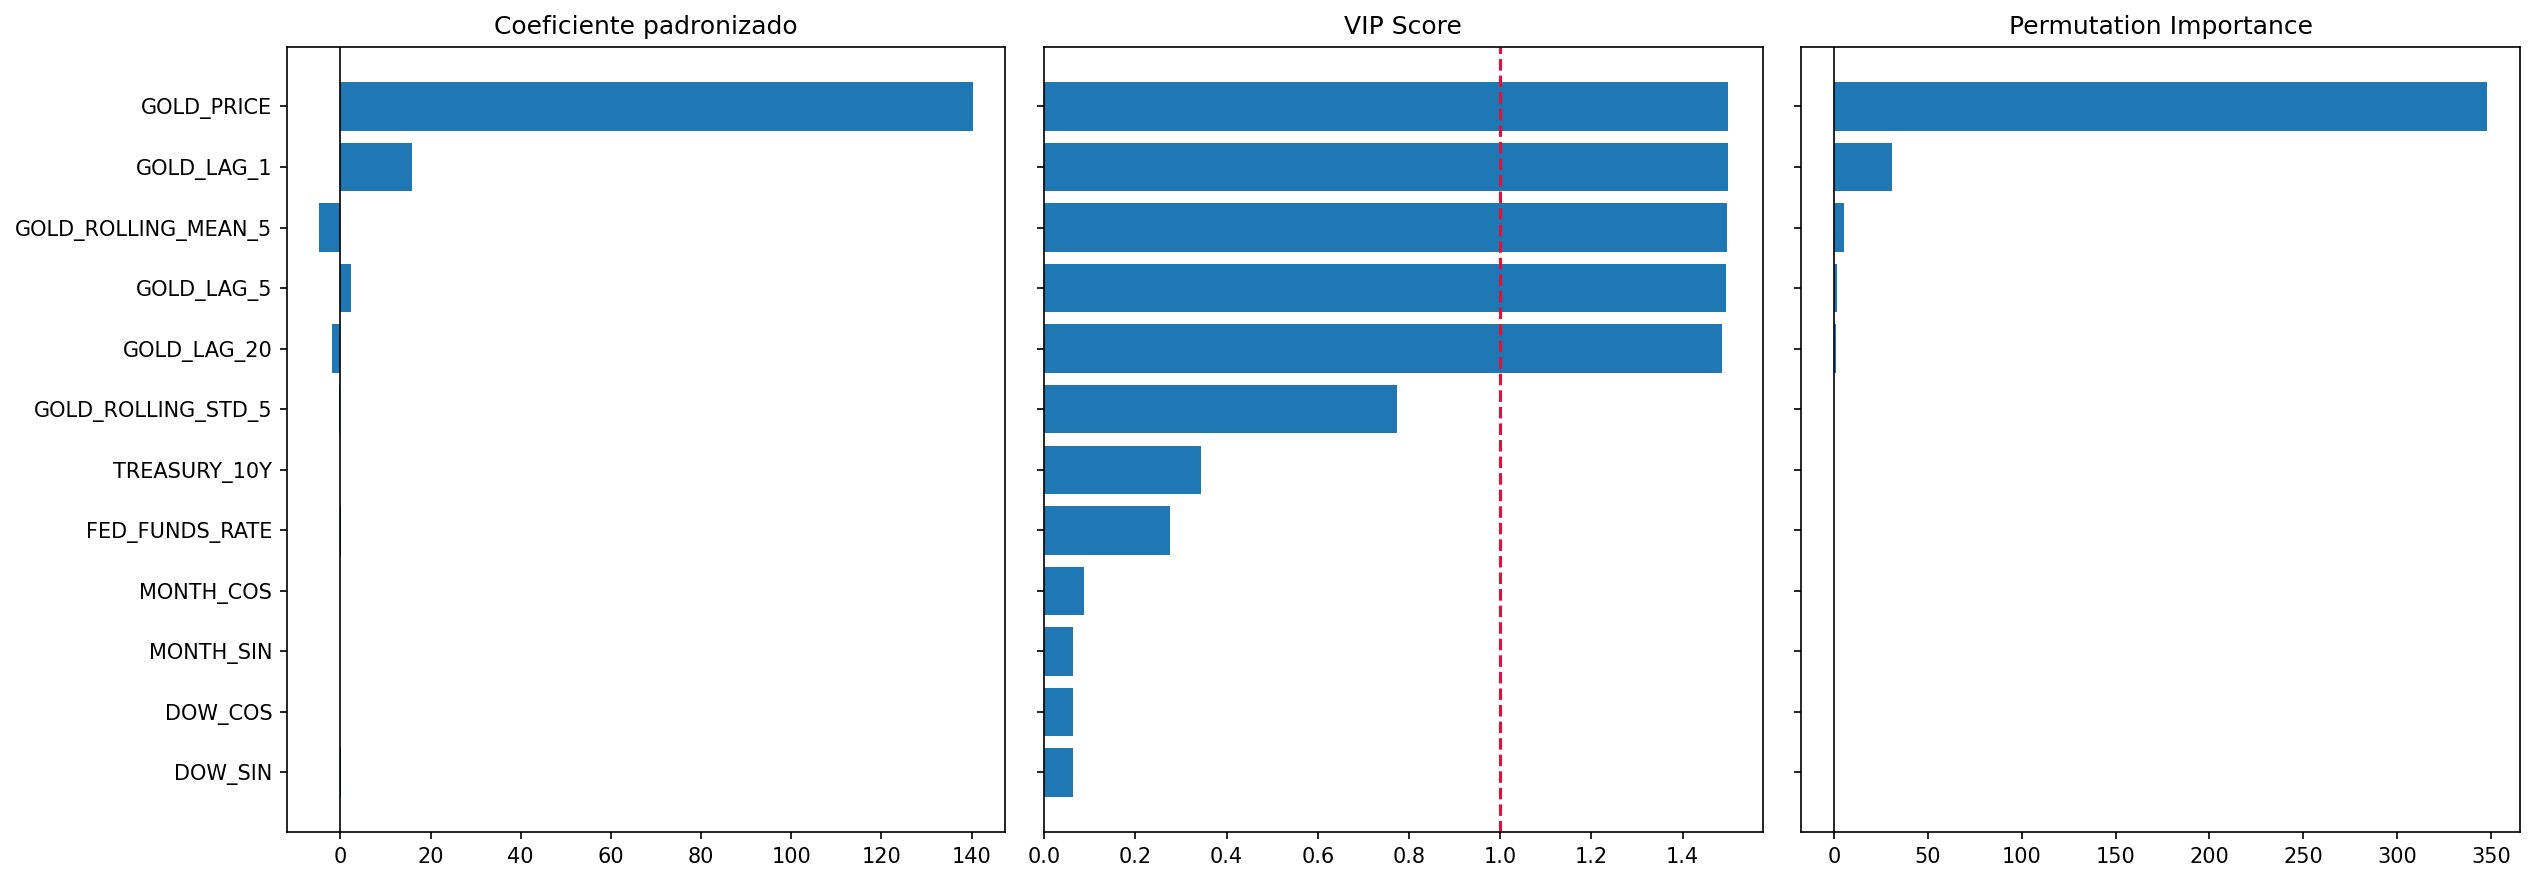

In [9]:
display(pd.read_csv(OUT / 'pls_feature_interpretation.csv').head(8).round(4))
figure('pls_feature_interpretation.png', 900)

## 9. V2 complementar: LEVEL, DELTA e LOG_RETURN

A V2 foi concluída como estudo complementar no commit `d6f67bd`. Ela não reabre o ranking V1. No RF A8, transformar LEVEL em DELTA ou LOG_RETURN reduziu fortemente o erro reconstruído em preço: 39,5007 no nível, 12,1579 em delta e 11,7850 em log-retorno. Mesmo assim, DELTA e LOG_RETURN A8 não superaram persistência.

O menor MAE experimental foi RF/LOG_RETURN/A3, 11,2986, ganho de 0,3390 USD/onça (2,91%) sobre persistência e acurácia direcional de 53,72%. Esse resultado é `INFORMATIVE`, pois surgiu em especificação experimental posterior. Ele orienta pesquisa futura, mas não é sucessor oficial de Holt-Winters.

model,feature_set,target,mae_usd,directional_accuracy,status
RF,A8_technical_all_core,LEVEL,39.5007,0.5169,INFORMATIVE
RF,A8_technical_all_core,DELTA,12.1579,0.4932,INFORMATIVE
RF,A8_technical_all_core,LOG_RETURN,11.7850,0.5304,INFORMATIVE
RF,A3_gold_technical_no_raw,LOG_RETURN,11.2986,0.5372,INFORMATIVE


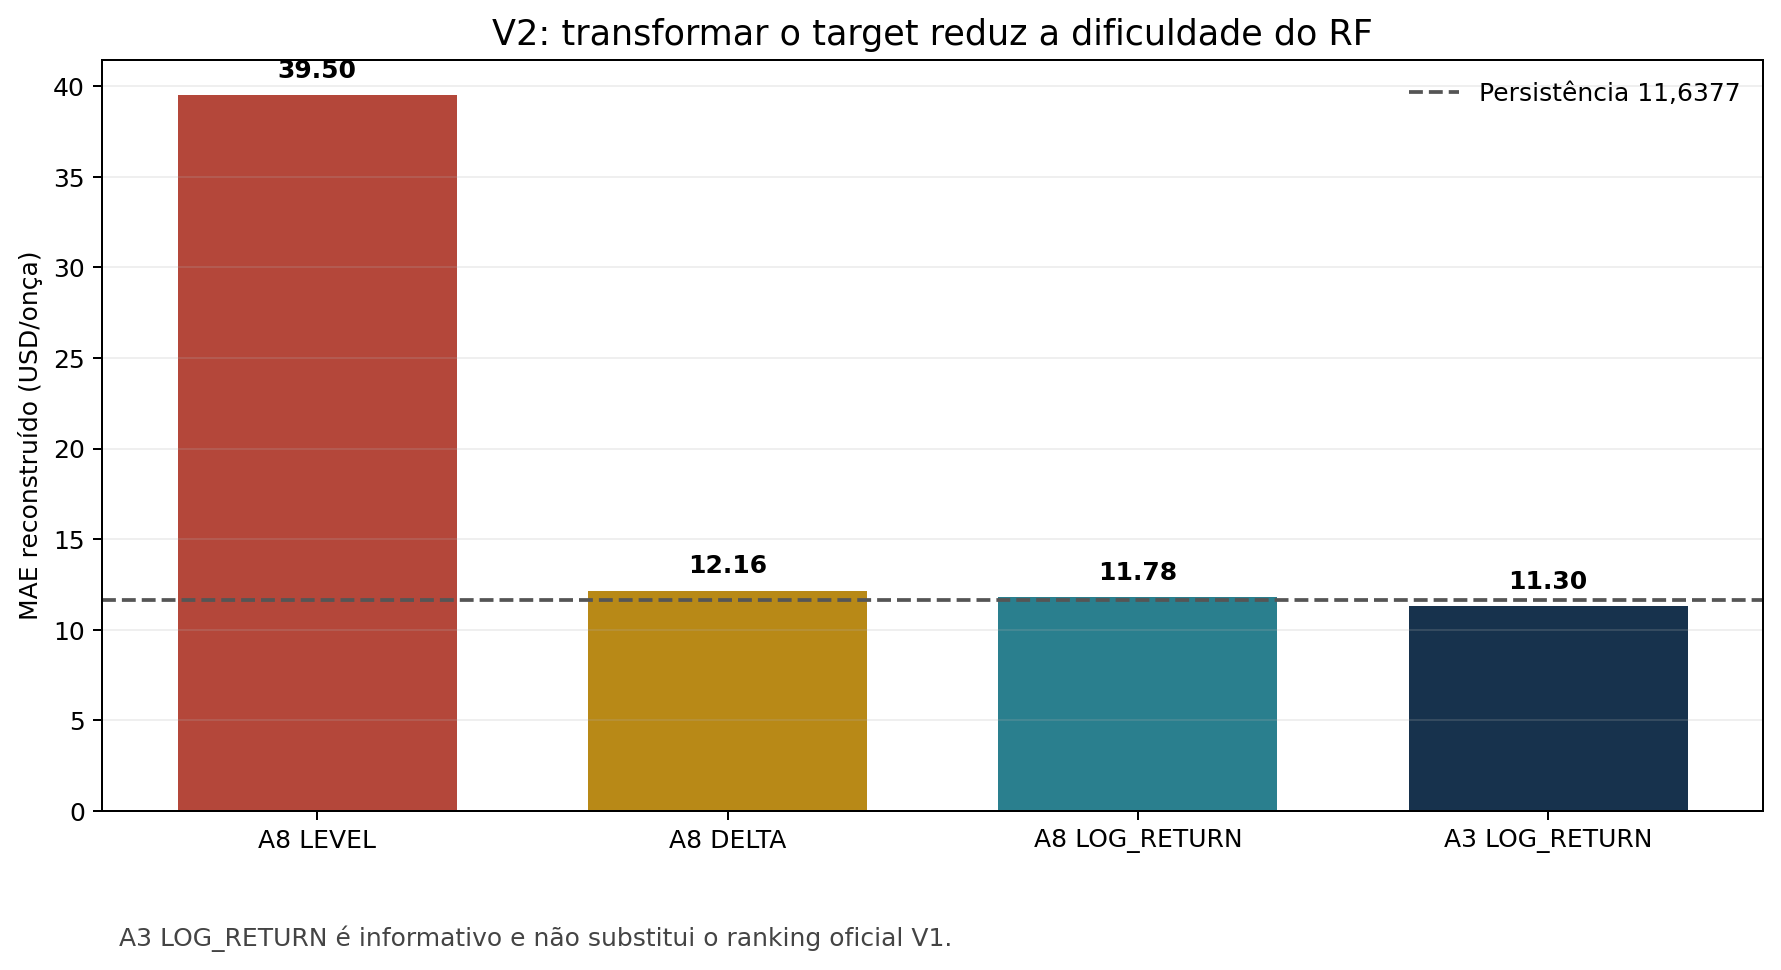

In [10]:
targets = pd.read_csv(V2 / 'target_comparison_selected.csv')
display(targets[['model','feature_set','target','mae_usd','directional_accuracy','status']].round(4))
report_figure('v2_targets.png', 980)

## 10. V2 complementar: ablation, extrapolação, drift e redundância

Na ablation RF LEVEL FULL, remover `GOLD_PRICE` piorou o MAE em 2,0914 USD/onça, cerca de 14%. Remover todos os lags trouxe melhora pequena de 0,2929, mas o resultado continuou pior que persistência. Usar somente exógenas produziu MAE 38,1406. Mais features não garantiram melhora, e exógenas não substituíram a dinâmica autorregressiva neste horizonte.

No diagnóstico RF A8, `y_train` variou de 252,90 a 725,75 e `y_test` de 647,75 a 1.877,75. Em 281 de 296 origens, 94,9%, o alvo real superou o máximo visto no treino. Como árvores predizem por médias em folhas, não extrapolam naturalmente novos níveis. Drift em WTI, juros, dólar, índice acionário e volatilidade do ouro agravou a mudança de distribuição.

Também houve redundância: DGS2 e seu lag 1 (~0,9997), VIX e seu lag (~0,9818), e distância da média 20 com momentum 10 (~0,9289). A estabilidade temporal das importâncias é `NOT_ASSESSABLE_SINGLE_TEST_PERIOD`; há um único período de teste, logo drift e permutação são diagnósticos descritivos.

feature_set,mae_usd,absolute_difference_vs_full,n_features
FULL,14.9906,0.0000,39
FULL_without_GOLD_PRICE,17.0820,2.0914,38
FULL_without_gold_lags,14.6976,-0.2929,23
A4_exogenous_only,38.1406,23.1500,7


feature,standardized_mean_shift
DCOILWTICO,3.4250
DGS2,-2.1746
dgs2_lag1,-2.1710
yield_curve_slope,1.3751
DTWEXB,-1.1297
gold_rv_60,1.0256
NASDAQCOM,0.8929
gold_rv_20,0.8580


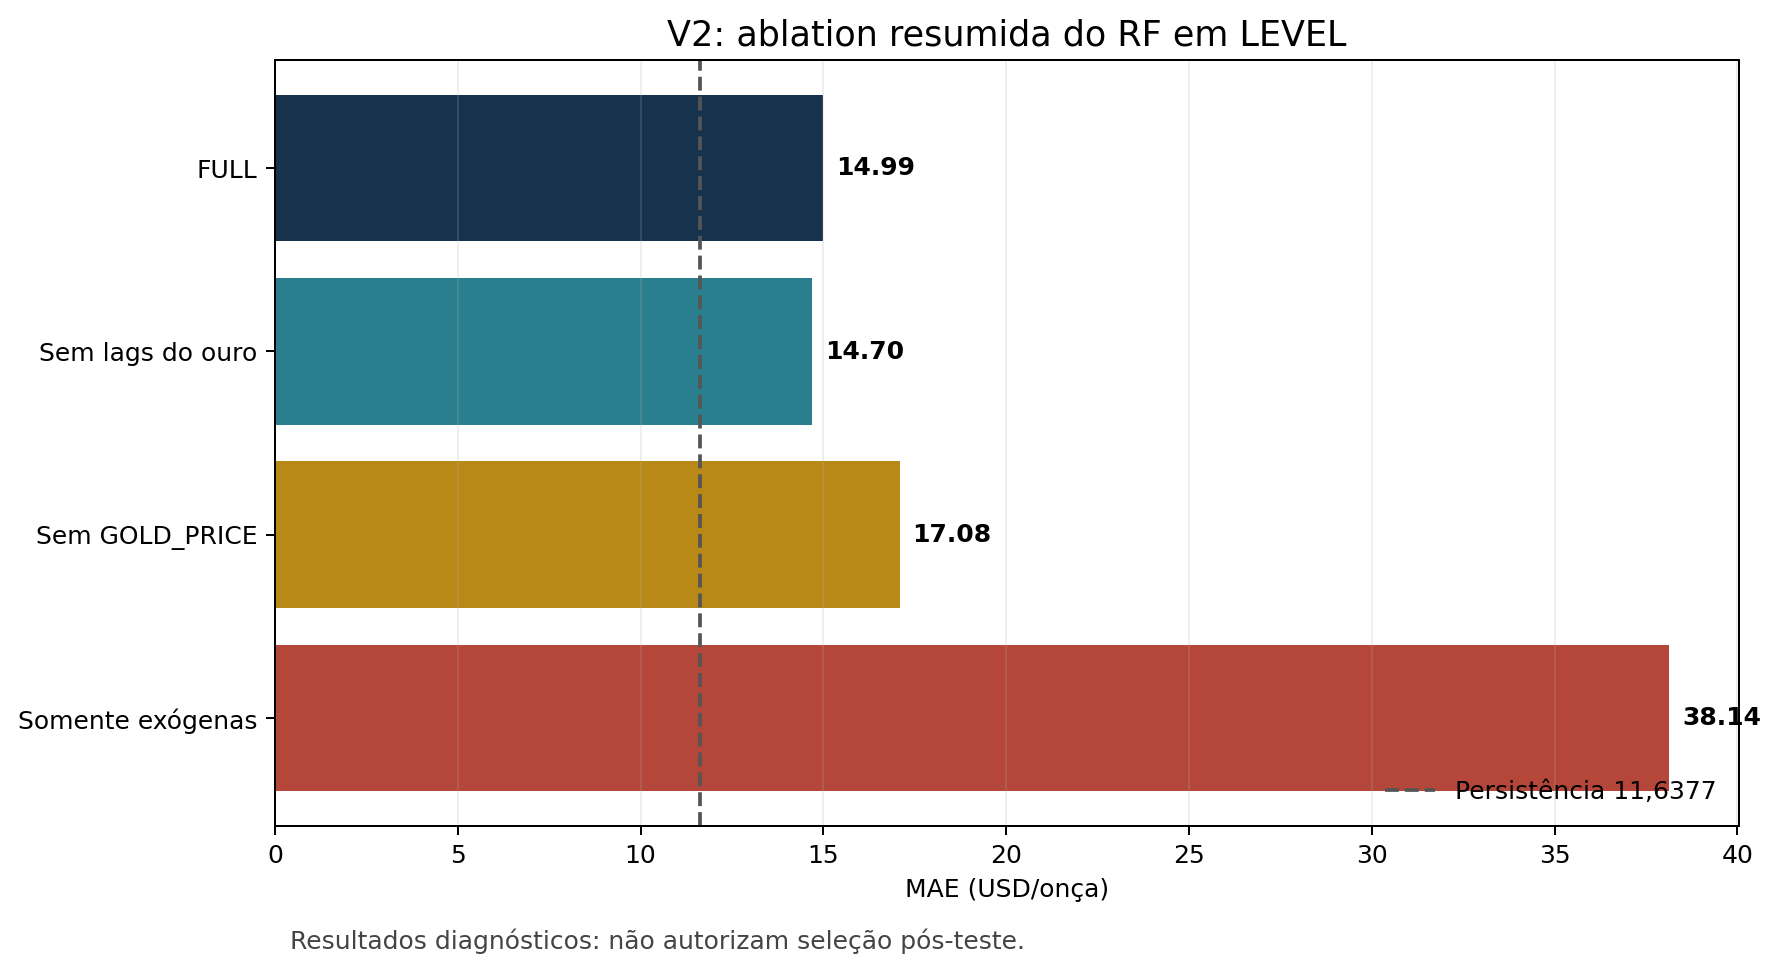

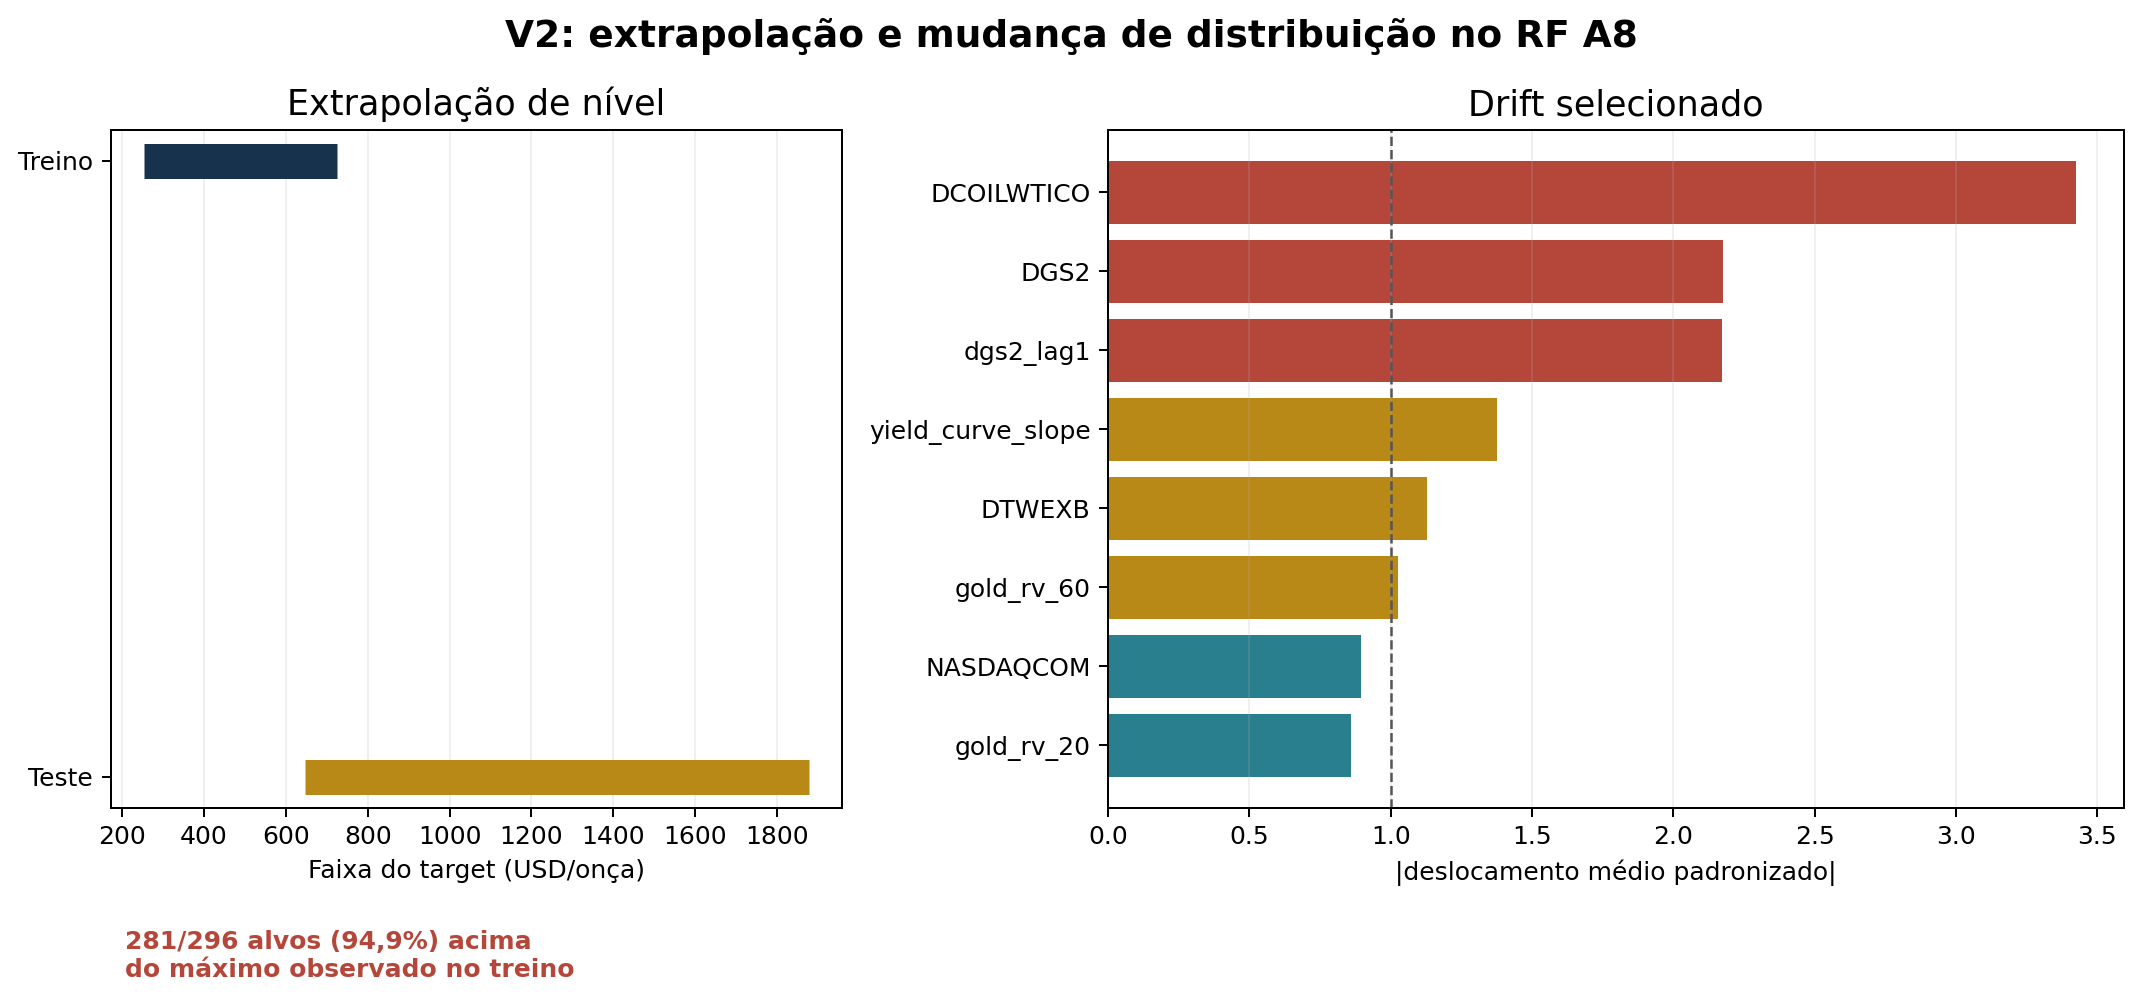

In [11]:
abl = pd.read_csv(V2 / 'ablation_selected.csv')
display(abl[['feature_set','mae_usd','absolute_difference_vs_full','n_features']].round(4))
drift = pd.read_csv(V2 / 'rf_a8_feature_drift_selected.csv')
display(drift[['feature','standardized_mean_shift']].round(4))
report_figure('v2_ablation.png', 980)
report_figure('v2_rf_drift_extrapolacao.png', 980)

## 11. Validação V2 e ressalva de metadado

A evidência final da V2 registra 99 experimentos canônicos, todos com 296 origens, previsões finitas, origens únicas, MAE reproduzido e reconstrução correta de preço para DELTA e LOG_RETURN. A Stage B está concluída; o antigo `V2_STATUS.md` com itens `deferred/not run` ficou desatualizado diante dos achados e da validação final de `d6f67bd`.

O estado correto é **PASS_WITH_METADATA_RECONCILIATION_REQUIRED**. Nos arquivos brutos V2, `target_date` contém a data da origem. As tabelas consolidadas recuperam a data-alvo correta pelo manifesto V1 congelado. A reconciliação altera apenas o rótulo de metadado: previsões, `Y_TRUE`, as 296 origens e os MAEs permanecem intactos.

In [12]:
validation = json.loads((V2 / 'v2_validation_summary.json').read_text(encoding='utf-8'))
display(pd.DataFrame([{
    'status': validation['validation_status'],
    'experimentos': validation['canonical_experiments'],
    'origens_por_experimento': validation['expected_origins_per_experiment'],
    'V1_byte_identical': validation['v1_byte_identical'],
    'Stage_B': validation['stage_b_status'],
}]))

status,experimentos,origens_por_experimento,V1_byte_identical,Stage_B
PASS_WITH_METADATA_RECONCILIATION_REQUIRED,99,296,True,completed


## 12. Limitações e conclusão

As conclusões estão limitadas à série histórica até 2014, horizonte de uma observação e calendário irregular. As externas seguem regra conservadora, sem vintages intradiários completos. O ganho do melhor modelo sobre persistência é pequeno. A importância não é causal e sua estabilidade entre regimes não foi demonstrada. A V2 explorou um único teste e não autoriza seleção pós-teste.

A conclusão oficial permanece: Holt-Winters 11,5331; SARIMAX 11,5988; PLS 11,6002; Random Forest 14,2826. Persistência marcou 11,6377 fora do ranking. Os três primeiros ficaram praticamente empatados. RF em LEVEL foi prejudicado por extrapolação, drift, redundância, maior dispersão e estrutura residual remanescente.

A V2 mostra que DELTA e LOG_RETURN são caminhos promissores para um protocolo futuro com seleção pré-teste, períodos independentes e dados mais recentes. Nesta entrega, V1 é a referência oficial e V2 é explicação complementar.

In [13]:
display(pd.DataFrame({
    'camada': ['V1 oficial','Baseline diagnóstico','V2 complementar'],
    'uso': ['ranking e conclusão','contextualizar dificuldade','explicar limites e orientar pesquisa'],
    'altera ranking V1': ['não','não','não'],
}))

camada,uso,altera ranking V1
V1 oficial,ranking e conclusão,não
Baseline diagnóstico,contextualizar dificuldade,não
V2 complementar,explicar limites e orientar pesquisa,não


## 13. Referências, apêndice e governança

As referências completas estão em `REFERENCIAS_OURO.md`, separadas entre fonte institucional, URL de aquisição, séries externas, artigos e bibliotecas. O apêndice técnico lista protocolo, tuning, resíduos, Ljung-Box, auditorias, V2, hashes e ressalvas. O checklist distingue requisitos locais de itens dependentes das cinco bases ou do grupo.

Artefatos congelados protegidos: base modelada, `predictions.csv`, `metrics.csv`, `hyperparameters.csv`, `protocol.json` e os 24 notebooks técnicos da V1. A finalização não executou tuning, treinamento, walk-forward ou otimização.

Documentos associados: `APENDICE_TECNICO_OURO.md`, `CHECKLIST_ATIVIDADE_OURO.md`, `ROTEIRO_APRESENTACAO_OURO.md`, `REFERENCIAS_OURO.md` e `MANIFESTO_ENTREGA_OURO.md`.

In [14]:
hashes = pd.DataFrame([
    ('gold_daily_modeling.csv','38622FE40A18C3E94B89971488468F762353ED4234234E054F0439918CB5D1AC'),
    ('predictions.csv','83C52112B6DDE640F520F3F870D30F0927CB4A03103098B4C284B24662AC6EC0'),
    ('metrics.csv','F9FE5418EB7F5F14357ADA49BA64B7264282A148B81D3B2F792AE673F708E92E'),
    ('hyperparameters.csv','4CB56A13CB6CC3A31B8ACC60E2BB3DD3ECEAE1448EB698D39B1540BFC5203886'),
    ('protocol.json','21F258988ABF0E585F426137F8FD16943997985C01F0AAFE204445F6481D74C5'),
], columns=['artefato','SHA-256'])
display(hashes)

artefato,SHA-256
gold_daily_modeling.csv,38622FE40A18C3E94B89971488468F762353ED4234234E054F0439918CB5D1AC
predictions.csv,83C52112B6DDE640F520F3F870D30F0927CB4A03103098B4C284B24662AC6EC0
metrics.csv,F9FE5418EB7F5F14357ADA49BA64B7264282A148B81D3B2F792AE673F708E92E
hyperparameters.csv,4CB56A13CB6CC3A31B8ACC60E2BB3DD3ECEAE1448EB698D39B1540BFC5203886
protocol.json,21F258988ABF0E585F426137F8FD16943997985C01F0AAFE204445F6481D74C5
